# Required packages

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import kstest_normal
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

In [3]:
from itertools import product
from tqdm.notebook import tqdm
from typing import Union
import warnings
import joblib

# 8.1) Examining the $SARIMA(p, d, q) (P, D, Q)_m$ model

In [4]:
df_passengers = pd.read_csv('data/air-passengers.csv')
df_passengers['Month'] = pd.to_datetime(df_passengers.Month)

In [5]:
df_passengers.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [6]:
df_passengers.set_index('Month', inplace=True)

In [7]:
df_passengers.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


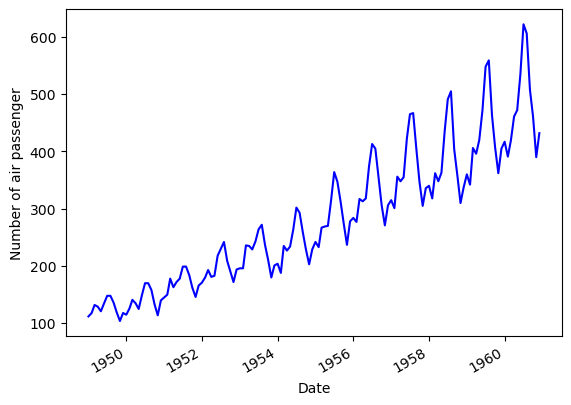

In [8]:
fig, ax = plt.subplots()
ax.plot(df_passengers.Passengers, 'b-')
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passenger')
fig.autofmt_xdate()
plt.show()

# 8.2) Identifying seasonal patterns in a time series

In [9]:
decomposition = STL(df_passengers.Passengers, period=12).fit()

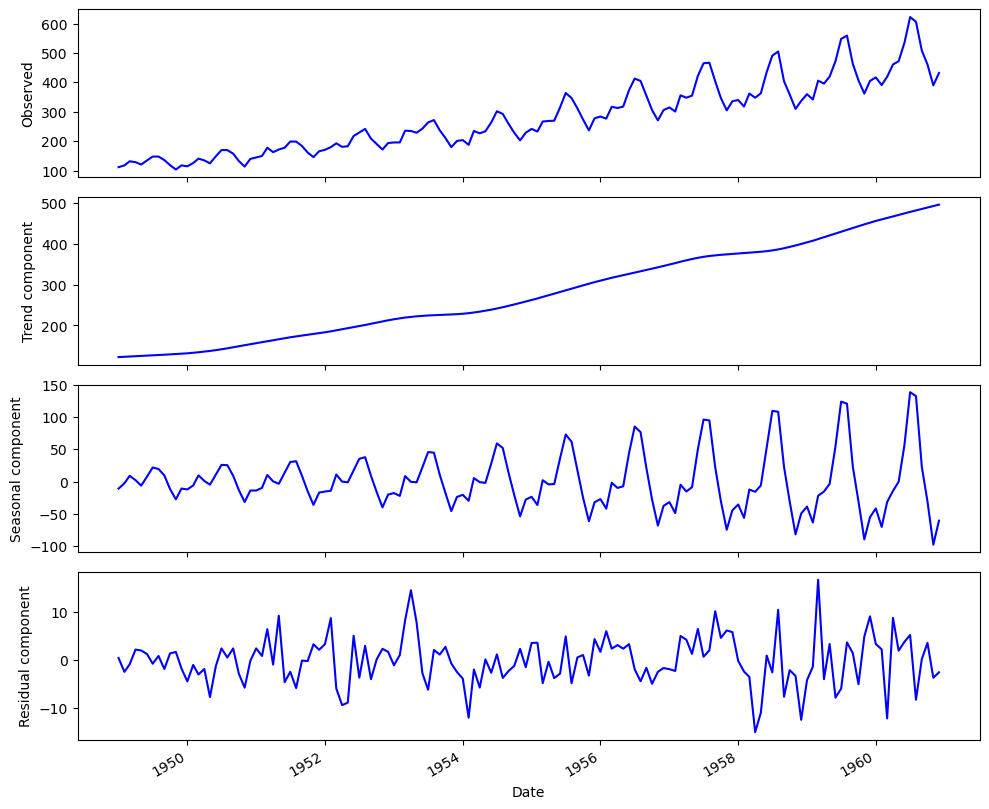

In [10]:
fig, ax = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
ax[0].plot(decomposition.observed, 'b-')
ax[0].set_ylabel('Observed')

ax[1].plot(decomposition.trend, 'b-')
ax[1].set_ylabel('Trend component')

ax[2].plot(decomposition.seasonal, 'b-')
ax[2].set_ylabel('Seasonal component')

ax[3].plot(decomposition.resid, 'b-')
ax[3].set_ylabel('Residual component')

fig.autofmt_xdate()
fig.tight_layout()

ax[3].set_xlabel('Date')

plt.show()

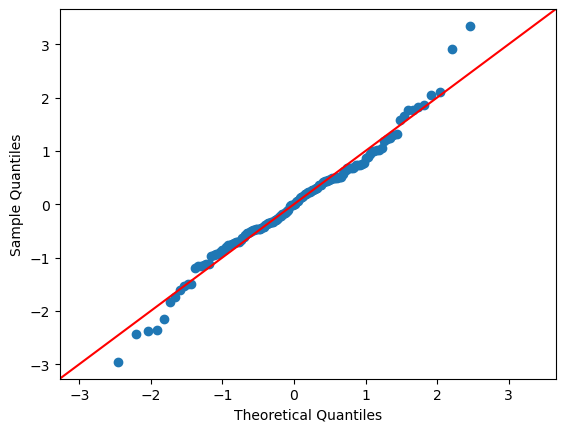

In [11]:
resid = (decomposition.resid - np.mean(decomposition.resid)) / np.std(decomposition.resid, ddof=1)
qqplot(resid, line='45');

In [12]:
np.mean(decomposition.resid)

np.float64(-0.16863466812152428)

In [13]:
kstest_normal(decomposition.resid)

(np.float64(0.058829362646678374), np.float64(0.3290519014815855))

## Test with a time series without seasonality and trend

In [14]:
series = ArmaProcess(ar=[-0.5], ma=[0.5]).generate_sample(nsample=100)

In [15]:
decomposition_arma = STL(series, period=12).fit()

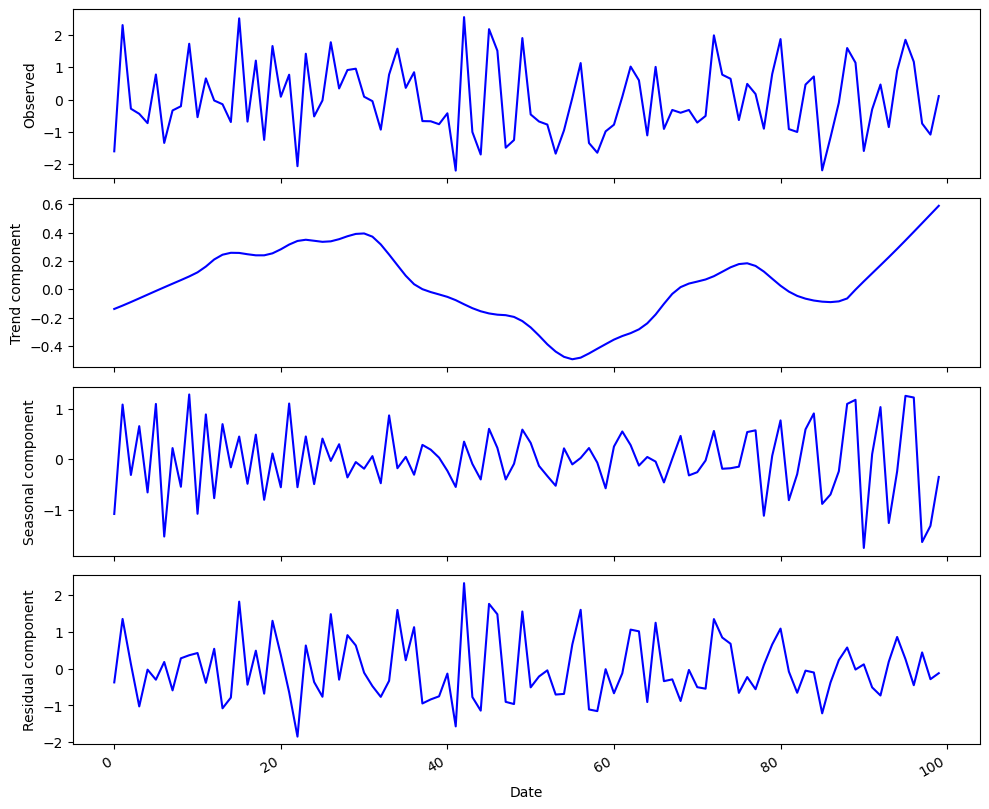

In [16]:
fig, ax = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
ax[0].plot(decomposition_arma.observed, 'b-')
ax[0].set_ylabel('Observed')

ax[1].plot(decomposition_arma.trend, 'b-')
ax[1].set_ylabel('Trend component')

ax[2].plot(decomposition_arma.seasonal, 'b-')
ax[2].set_ylabel('Seasonal component')

ax[3].plot(decomposition_arma.resid, 'b-')
ax[3].set_ylabel('Residual component')

fig.autofmt_xdate()
fig.tight_layout()

ax[3].set_xlabel('Date')

plt.show()

# 8.3) Forecasting the number of monthly air passengers

## 8.3.1) Forecasting with ARIMA(p, d, q) model

In [17]:
df_passengers.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [18]:
df_passengers.loc["1960-01":]

,Passengers
Month,
1960-01-01,417
1960-02-01,391
1960-03-01,419
1960-04-01,461
1960-05-01,472
1960-06-01,535
1960-07-01,622
1960-08-01,606
1960-09-01,508


### Defining $d$

In [19]:
adfuller(df_passengers.iloc[:, 0])

(np.float64(0.8153688792060472),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.6929308390189))

In [20]:
passengers_diff = np.diff(df_passengers.iloc[:, 0], n=1)

In [21]:
adfuller(passengers_diff)

(np.float64(-2.8292668241699905),
 np.float64(0.05421329028382671),
 12,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.5069317854084))

In [22]:
passengers_diff2 = np.diff(df_passengers.iloc[:, 0], n=2)

In [23]:
adfuller(passengers_diff2)

(np.float64(-16.384231542468463),
 np.float64(2.732891850014476e-29),
 11,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.6020417275611))

### Specifying the suitable orders

In [24]:
arima_order_list = list(product(
    np.arange(0, 13, 1), [2], np.arange(0, 13, 1), [0], [0], [0]
))

In [25]:
arima_order_list[:4]

[(np.int64(0), 2, np.int64(0), 0, 0, 0),
 (np.int64(0), 2, np.int64(1), 0, 0, 0),
 (np.int64(0), 2, np.int64(2), 0, 0, 0),
 (np.int64(0), 2, np.int64(3), 0, 0, 0)]

### Function to choose the order

In [26]:
def optimize_sarima(series: Union[list, pd.Series], order_list: list, s: int) -> pd.DataFrame:
    """
    Choose the p, q, P, Q parameters in the SARIMA model.

    Params:
    -------
    series: Union[list, pd.Series]
        time series 
    order_list: list
        a list with all options of p, d, q, P, D,  Q
    s: int
        seasonal frequency (size of seasonal period)

    Returns:
    -------
        a dataframe with eight columns: p, d, q, P, D, Q, m, AIC
    """

    results = []
    for order in tqdm(order_list):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = SARIMAX(
                    series, order = order[:3], seasonal_order=(*order[3:], s)
                ).fit(disp=False)
        except:
            continue
        results.append([*order, s, model.aic])

    return pd.DataFrame(
        results,
        columns=['p', 'd', 'q', 'P', 'D', 'Q', 'm', 'AIC']
    ).sort_values(by='AIC', ascending=True).reset_index(drop=True)

### Splitting train and test

In [27]:
train = df_passengers[:-12].copy().asfreq('MS')
test = df_passengers[-12:].copy().asfreq('MS')

### Choosing the order by AIC

In [28]:
arima_result_aic_df = optimize_sarima(
    train.iloc[:, 0],
    arima_order_list,
    12
)

  0%|          | 0/169 [00:00<?, ?it/s]

In [29]:
arima_result_aic_df.head()

,p,d,q,P,D,Q,m,AIC
0,11,2,3,0,0,0,12,1016.876132
1,11,2,4,0,0,0,12,1019.012824
2,11,2,5,0,0,0,12,1020.427116
3,12,2,0,0,0,0,12,1020.624874
4,11,2,1,0,0,0,12,1021.020774


### cheching the goodness of fit

In [30]:
model = SARIMAX(train.iloc[:, 0], order=(11, 2, 3)).fit(disp=False)

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


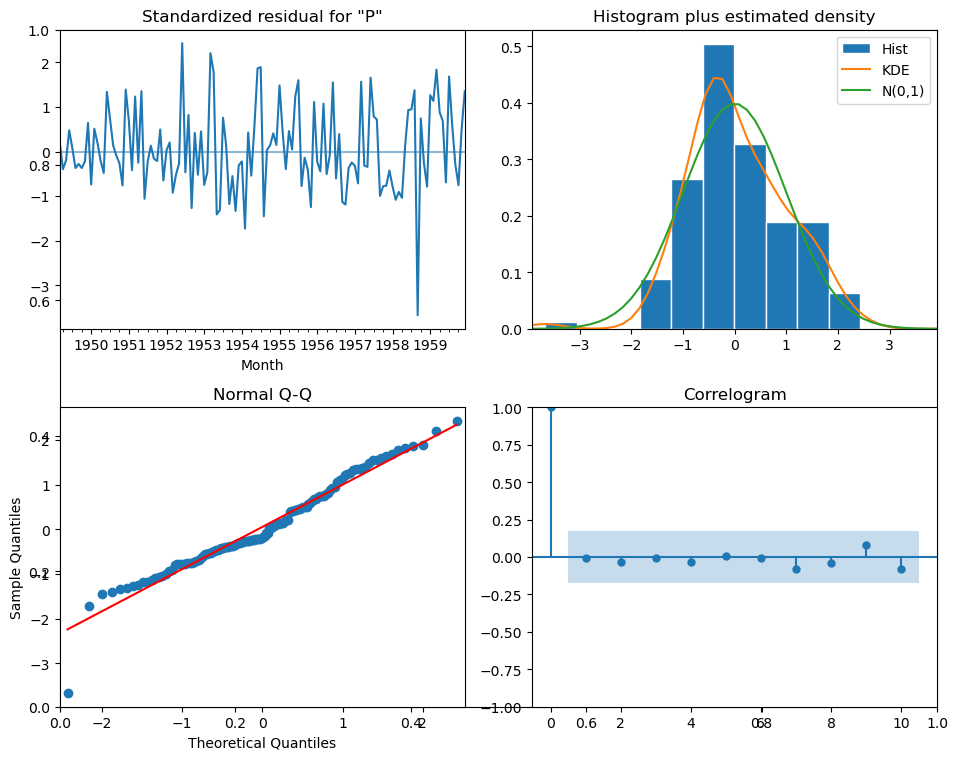

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
model.plot_diagnostics(fig=fig)
fig.tight_layout()
plt.show()

In [32]:
ljungbox_df = acorr_ljungbox(model.resid)

In [33]:
ljungbox_df

,lb_stat,lb_pvalue
1,6.532249,0.010594
2,6.640276,0.036148
3,6.902114,0.075084
4,7.722050,0.102307
5,8.359122,0.137523
6,8.668036,0.193126
7,9.526203,0.217050
8,9.754443,0.282686
9,9.763811,0.369942
10,11.534901,0.317388


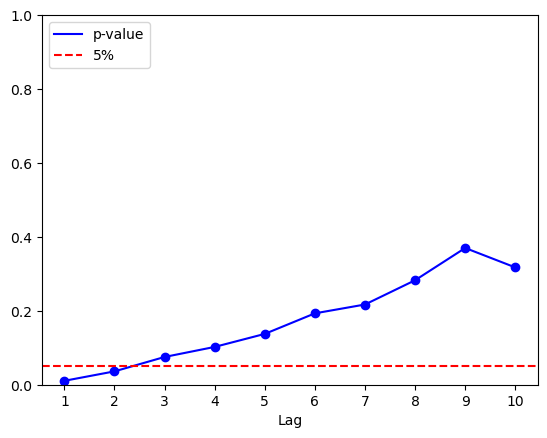

In [34]:
fig, ax = plt.subplots()
ax.plot(ljungbox_df.lb_pvalue, 'b-', label='p-value')
ax.plot(ljungbox_df.lb_pvalue, 'bo')
ax.axhline(0.05, color='r', linestyle='--', label='5%')
ax.set_xlabel('Lag')
ax.set_xticks(np.arange(1, 11, 1))
ax.set_ylim([0, 1])
ax.legend(loc='upper left')
plt.show()

In [35]:
df_passengers.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 6.3 KB


### Seasonal predictions

In [36]:
df_pred = pd.DataFrame({
    'observed': test.iloc[:, 0].values,
    'seasonal': train.iloc[-12:, 0].values
}, index=test.index)

In [37]:
df_pred

,observed,seasonal
Month,,
1960-01-01,417,360
1960-02-01,391,342
1960-03-01,419,406
1960-04-01,461,396
1960-05-01,472,420
1960-06-01,535,472
1960-07-01,622,548
1960-08-01,606,559
1960-09-01,508,463


### Arima predictions

In [38]:
df_pred['arima'] = model.get_prediction(0, train.shape[0] + 12 - 1).predicted_mean[-12:]

In [39]:
df_pred

,observed,seasonal,arima
Month,,,
1960-01-01,417,360,422.189878
1960-02-01,391,342,410.548836
1960-03-01,419,406,461.599222
1960-04-01,461,396,457.401337
1960-05-01,472,420,481.450278
1960-06-01,535,472,530.729753
1960-07-01,622,548,606.040377
1960-08-01,606,559,615.352591
1960-09-01,508,463,525.702716


## 8.3.2) Forecasting with $SARIMA(p,d,q)(P, D, Q)_m$ model

In [40]:
adfuller(df_passengers.iloc[:, 0])

(np.float64(0.8153688792060472),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.6929308390189))

In [41]:
diff_seasonal = np.diff(df_passengers['Passengers'], n=12)

In [42]:
adfuller(diff_seasonal)

(np.float64(-16.343415591720582),
 np.float64(2.980503971529278e-29),
 13,
 118,
 {'1%': np.float64(-3.4870216863700767),
  '5%': np.float64(-2.8863625166643136),
  '10%': np.float64(-2.580009026141913)},
 np.float64(1556.0019321685338))

In [43]:
adfuller(np.diff(df_passengers['Passengers'], n=2))

(np.float64(-16.384231542468463),
 np.float64(2.732891850014476e-29),
 11,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.6020417275611))

In [44]:
adfuller(np.diff(df_passengers['Passengers'], n=1))

(np.float64(-2.8292668241699905),
 np.float64(0.05421329028382671),
 12,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.5069317854084))

### Specifying the suitabale orders

In [45]:
order_list = list(product(
    np.arange(0, 4, 1), [1], np.arange(0, 4, 1),
    np.arange(0, 4, 1), [1], np.arange(0, 4, 1)
))

In [46]:
len(order_list)

256

### Choosing order by AIC

In [47]:
?optimize_sarima

Signature: optimize_sarima(series: list | pandas.Series, order_list: list, s: int) -> pandas.DataFrame
Docstring:
Choose the p, q, P, Q parameters in the SARIMA model.

Params:
-------
series: Union[list, pd.Series]
    time series 
order_list: list
    a list with all options of p, d, q, P, D,  Q
s: int
    seasonal frequency (size of seasonal period)

Returns:
-------
    a dataframe with eight columns: p, d, q, P, D, Q, m, AIC
File:      /tmp/ipykernel_8271/4056831016.py
Type:      function

In [48]:
sarima_aic = joblib.load('output/sarima_aic.pkl')

In [49]:
sarima_aic.head(n=20)

,p,d,q,P,D,Q,m,AIC
0,2,1,1,1,1,2,12,892.233948
1,2,1,1,2,1,1,12,893.315599
2,2,1,1,1,1,3,12,894.110307
3,1,1,0,1,1,2,12,894.289792
4,0,1,1,1,1,2,12,894.993271
5,1,1,0,2,1,1,12,895.091048
6,3,1,1,1,1,2,12,895.626358
7,0,1,3,1,1,2,12,895.654749
8,2,1,2,1,1,2,12,895.767950
9,0,1,1,2,1,1,12,896.021217


### Checking the Goodness of Fit

In [50]:
model_fit_sarima = SARIMAX(
    df_passengers['Passengers'].values,
    order=(2, 1, 1), seasonal_order=(1, 1, 2, 12)).fit(disp=False)

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


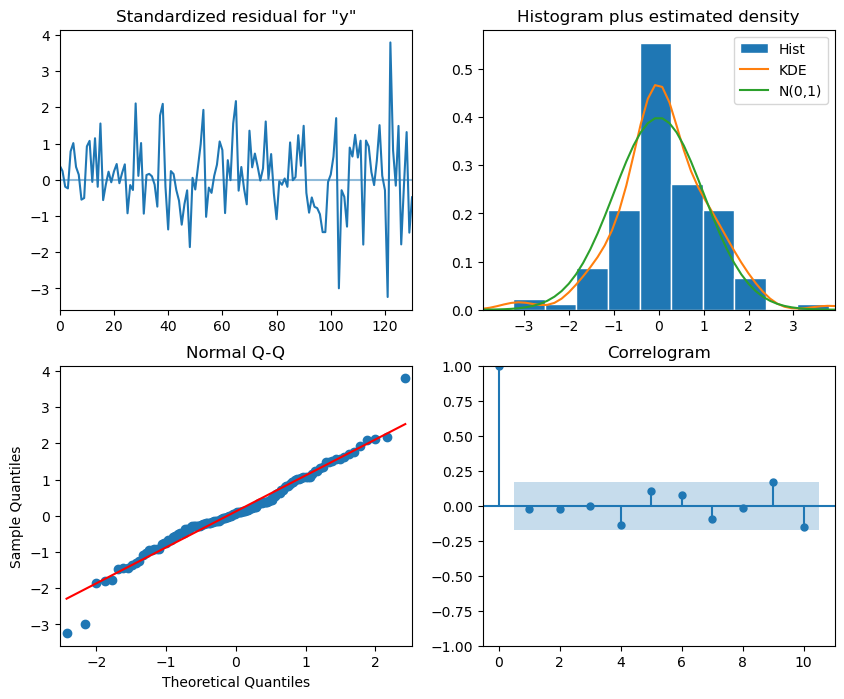

In [51]:
model_fit_sarima.plot_diagnostics(figsize=(10, 8));

In [52]:
df_lb = acorr_ljungbox(model_fit_sarima.resid, lags=20)

In [53]:
df_lb

,lb_stat,lb_pvalue
1,0.015564,0.900717
2,0.382082,0.826099
3,0.390774,0.942142
4,1.039771,0.903707
5,2.139890,0.829470
6,2.494537,0.869079
7,3.470133,0.838379
8,3.866599,0.868954
9,4.002030,0.911279
10,7.223492,0.704191


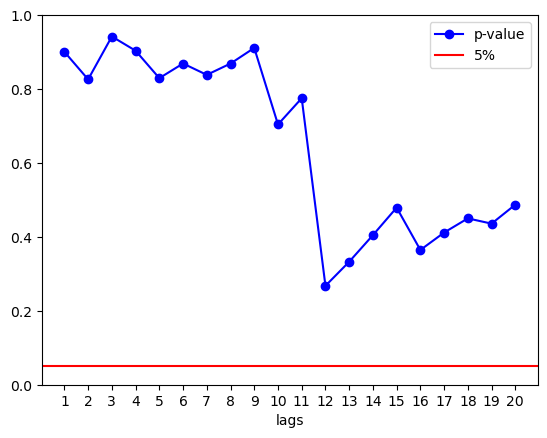

In [54]:
fig, ax = plt.subplots()
ax.plot(df_lb.lb_pvalue, 'b-o', label='p-value')
#ax.plot(df_lb.lb_pvalue, 'bo')
ax.axhline(0.05, color='red', label='5%')
ax.set_xlabel('lags')
ax.set_xticks(np.arange(1, 21, 1))
ax.set_ylim([0, 1])
ax.legend()
plt.show()

### Getting predictions with SARIMA

In [55]:
df_pred['sarima'] = model_fit_sarima.get_prediction(0, train.shape[0] + 12 - 1).predicted_mean[-12:]

In [56]:
df_pred

,observed,seasonal,arima,sarima
Month,,,,
1960-01-01,417,360,422.189878,415.855151
1960-02-01,391,342,410.548836,394.006796
1960-03-01,419,406,461.599222,452.909618
1960-04-01,461,396,457.401337,421.273185
1960-05-01,472,420,481.450278,463.498185
1960-06-01,535,472,530.729753,536.704513
1960-07-01,622,548,606.040377,606.417655
1960-08-01,606,559,615.352591,624.693145
1960-09-01,508,463,525.702716,509.831334


##  8.3.3) Comparing the performance of forecasting method

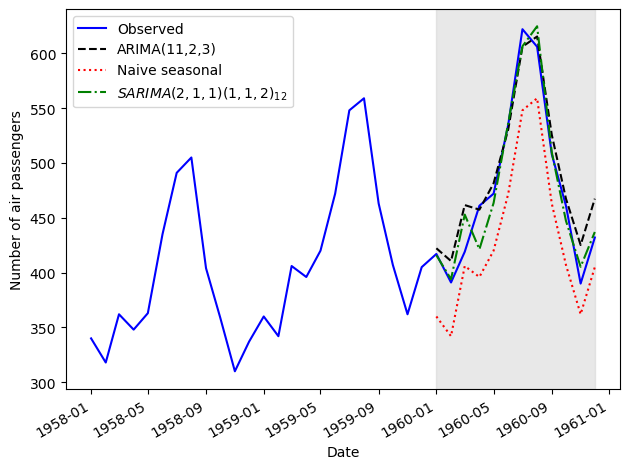

In [65]:
fig, ax = plt.subplots()
ax.plot(df_passengers.iloc[-36:, 0], 'b-', label='Observed')
ax.plot(df_pred['arima'],'k--', label='ARIMA(11,2,3)')
ax.plot(df_pred['seasonal'], 'r:', label='Naive seasonal')
ax.plot(df_pred['sarima'], 'g-.', label='$SARIMA(2, 1, 1)(1, 1, 2)_{12}$')
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
ax.legend()
ax.axvspan(
    df_pred.index[0], df_pred.index[-1],
    color='lightgray', alpha=0.5
)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### MAPE

In [67]:
mape = lambda y, p: 100 * np.mean(np.abs(
    (y - p)/y
))

In [68]:
metrics = pd.Series({
    'Naive seasonal': mape(df_pred['observed'], df_pred['seasonal']),
    'ARIMA': mape(df_pred['observed'], df_pred['arima']),
    'SARIMA': mape(df_pred['observed'], df_pred['sarima'])
})

In [69]:
metrics

Naive seasonal    9.987533
ARIMA             3.849218
SARIMA            2.825680
dtype: float64

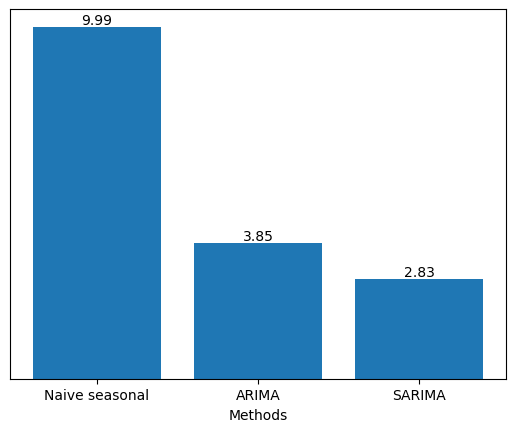

In [70]:
fig, ax = plt.subplots()
bars = ax.bar(metrics.index, metrics.values)
ax.bar_label(bars, fmt='%.2f')
ax.set_xlabel('Methods')
ax.set_ylabel('')
ax.set_yticks([])
plt.show()